# Automated Bridge Crack Detection: Baseline Model

This notebook implements the baseline model for bridge crack detection: a **patch-level Random Forest classifier**.

**Approach:**
- Extract 16x16 patches from the 448x448 input images.
- Compute hand-crafted features for each patch: Local Binary Patterns (LBP), Histogram of Oriented Gradients (HOG), and Intensity statistics.
- Train a Random Forest classifier with `class_weight='balanced'` to handle the extreme class imbalance (~1.5% crack pixels).
- Reconstruct patch-level predictions into full 448x448 segmentation masks.
- Evaluate using Recall, Dice/F1, and Mean IoU.

In [ ]:
!pip install scikit-image opencv-python albumentations -q

In [ ]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import glob
from collections import Counter
from tqdm.auto import tqdm
from skimage.feature import local_binary_pattern, hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

np.random.seed(42)

## 1. Data Setup & Loading

In [ ]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import glob
from collections import Counter
from tqdm.auto import tqdm
from skimage.feature import local_binary_pattern, hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

np.random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/bridge_crack_detection/dataset_split.zip'
EXTRACT_DIR = '/content/data'

os.makedirs(EXTRACT_DIR, exist_ok=True)

if os.path.exists(ZIP_PATH):
    print(f"Extracting {ZIP_PATH} to {EXTRACT_DIR}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete.")

    # Verify extracted contents and set DATA_DIR
    extracted_items = os.listdir(EXTRACT_DIR)
    print(f"Contents of {EXTRACT_DIR}: {extracted_items}")

    if 'dataset_split' in extracted_items:
        DATA_DIR = os.path.join(EXTRACT_DIR, 'dataset_split')
    elif len(extracted_items) == 1 and os.path.isdir(os.path.join(EXTRACT_DIR, extracted_items[0])):
        # If there's only one directory, assume it's the dataset root
        DATA_DIR = os.path.join(EXTRACT_DIR, extracted_items[0])
    else:
        DATA_DIR = EXTRACT_DIR # Assume files are directly in EXTRACT_DIR

    print(f"Final DATA_DIR set to: {DATA_DIR}")

else:
    print(f"Zip file not found at: {ZIP_PATH}")
    DATA_DIR = None # if zip not found

def get_file_pairs(split_name):
    if DATA_DIR is None or not os.path.exists(os.path.join(DATA_DIR, split_name)):
        print(f"Warning: {split_name} directory not found in {DATA_DIR}")
        return [], []

    split_dir = os.path.join(DATA_DIR, split_name)
    img_paths = sorted(glob.glob(os.path.join(split_dir, 'images', '*.*')))
    mask_paths = sorted(glob.glob(os.path.join(split_dir, 'masks', '*.*')))
    return img_paths, mask_paths

# Initialize lists + check if DATA_DIR exists before processing
train_imgs, train_masks, val_imgs, val_masks, test_imgs, test_masks = [], [], [], [], [], []

if DATA_DIR and os.path.exists(DATA_DIR):
    train_imgs, train_masks = get_file_pairs('train')
    val_imgs, val_masks = get_file_pairs('val')
    test_imgs, test_masks = get_file_pairs('test')
    print(f"Found {len(train_imgs)} training images, {len(val_imgs)} validation images, {len(test_imgs)} test images.")
else:
    print(f"Error: DATA_DIR '{DATA_DIR}' does not exist. Cannot load data.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting /content/drive/MyDrive/bridge_crack_detection/dataset_split.zip to /content/data...
Extraction complete.
Contents of /content/data: ['val', 'train', 'test']
Final DATA_DIR set to: /content/data
Found 220 training images, 47 validation images, 48 test images.


## 2. Patch Extraction & Feature Engineering

In [ ]:
PATCH_SIZE = 16

def extract_features(patch_rgb):
    patch_gray = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2GRAY)

    intensity_feats = np.array([np.mean(patch_gray), np.std(patch_gray)])

    n_points, radius = 8, 1
    lbp = local_binary_pattern(patch_gray, n_points, radius, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= (lbp_hist.sum() + 1e-6)

    hog_feats = hog(patch_gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)

    return np.concatenate((intensity_feats, lbp_hist, hog_feats))

def extract_patches_and_features(img_path, mask_path, is_train=False, background_subsample=0.1):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    features_list, labels_list = [], []

    h, w, _ = img.shape
    for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
        for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
            mask_patch = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            is_crack = (np.sum(mask_patch) > 0)
            label = 1 if is_crack else 0

            if is_train and not is_crack:
                if np.random.rand() > background_subsample:
                    continue

            patch = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            features_list.append(extract_features(patch))
            labels_list.append(label)

    return np.array(features_list), np.array(labels_list)

def process_dataset(img_paths, mask_paths, is_train=False, background_subsample=0.1):
    all_X, all_y = [], []
    for i, m in tqdm(zip(img_paths, mask_paths), total=len(img_paths)):
        X, y = extract_patches_and_features(i, m, is_train=is_train, background_subsample=background_subsample)
        all_X.append(X)
        all_y.append(y)
    return np.vstack(all_X), np.concatenate(all_y)

## 3. Train Model

In [ ]:
if os.path.exists(DATA_DIR) and len(train_imgs) > 0:
    X_train, y_train = process_dataset(train_imgs, train_masks, is_train=True, background_subsample=0.10)
    X_val, y_val = process_dataset(val_imgs, val_masks, is_train=False)

    clf = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced', n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)
    print(classification_report(y_val, clf.predict(X_val)))

  0%|          | 0/220 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     34746
           1       0.23      0.71      0.34      2102

    accuracy                           0.84     36848
   macro avg       0.60      0.78      0.63     36848
weighted avg       0.94      0.84      0.88     36848



## 4. Evaluation and Reconstruction

  0%|          | 0/48 [00:00<?, ?it/s]


Mean Recall:    0.7842
Mean Precision: 0.0738
Mean Dice/F1:   0.1291
Mean IoU:       0.0722


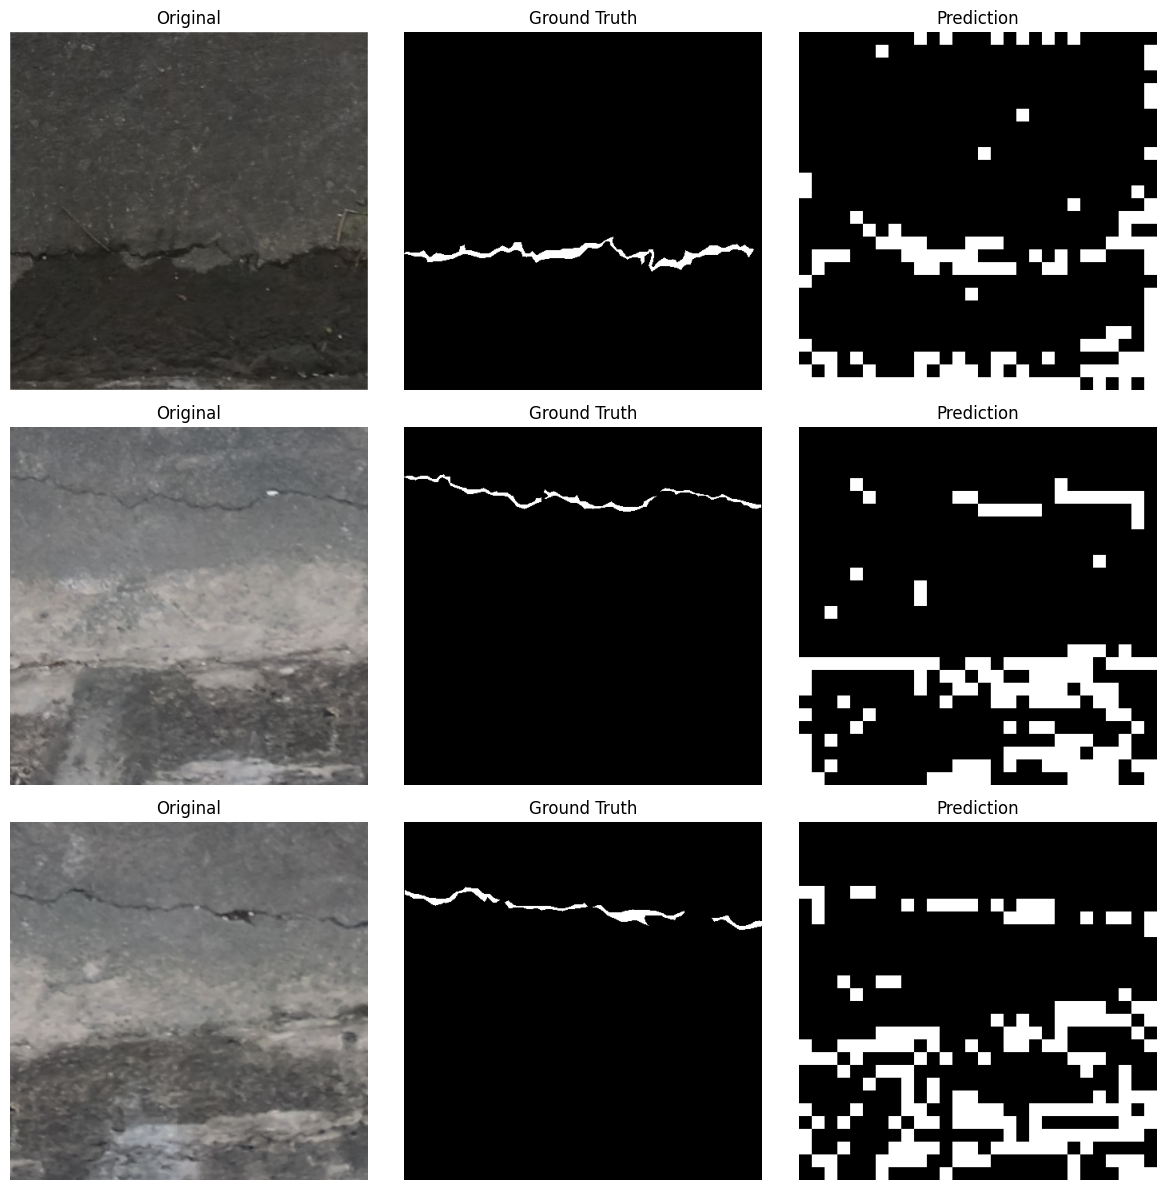

In [ ]:
def calculate_pixel_metrics(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    true_sum = np.sum(y_true)
    pred_sum = np.sum(y_pred)
    intersection_sum = np.sum(intersection)

    return (
        intersection_sum / (true_sum + 1e-6),              # recall
        intersection_sum / (pred_sum + 1e-6),              # precision
        (2. * intersection_sum) / (true_sum + pred_sum + 1e-6), # dice
        intersection_sum / (np.sum(union) + 1e-6)          # iou
    )

def predict_and_reconstruct(img_path, mask_path, model):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

    pred_mask = np.zeros_like(mask)
    features_list, coords = [], []

    h, w, _ = img.shape
    for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
        for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
            patch = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            features_list.append(extract_features(patch))
            coords.append((y, x))

    patch_preds = model.predict(np.array(features_list))
    for (y, x), pred in zip(coords, patch_preds):
        if pred == 1:
            pred_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = 1

    return img, mask, pred_mask

if os.path.exists(DATA_DIR) and len(test_imgs) > 0:
    all_metrics = {'recall': [], 'precision': [], 'dice': [], 'iou': []}
    vis_examples = []

    for img_p, mask_p in tqdm(zip(test_imgs, test_masks), total=len(test_imgs)):
        img, true_mask, pred_mask = predict_and_reconstruct(img_p, mask_p, clf)
        r, p, d, iou = calculate_pixel_metrics(true_mask.ravel(), pred_mask.ravel())

        all_metrics['recall'].append(r)
        all_metrics['precision'].append(p)
        all_metrics['dice'].append(d)
        all_metrics['iou'].append(iou)

        if np.sum(true_mask) > 0 and len(vis_examples) < 3:
            vis_examples.append((img, true_mask, pred_mask))

    print(f"\nMean Recall:    {np.mean(all_metrics['recall']):.4f}")
    print(f"Mean Precision: {np.mean(all_metrics['precision']):.4f}")
    print(f"Mean Dice/F1:   {np.mean(all_metrics['dice']):.4f}")
    print(f"Mean IoU:       {np.mean(all_metrics['iou']):.4f}")

    if len(vis_examples) > 0:
        fig, axes = plt.subplots(len(vis_examples), 3, figsize=(12, 4*len(vis_examples)))
        for idx, (im, tm, pm) in enumerate(vis_examples):
            ax = axes if len(vis_examples) == 1 else axes[idx]
            ax[0].imshow(im); ax[0].set_title("Original"); ax[0].axis('off')
            ax[1].imshow(tm, cmap='gray'); ax[1].set_title("Ground Truth"); ax[1].axis('off')
            ax[2].imshow(pm, cmap='gray'); ax[2].set_title("Prediction"); ax[2].axis('off')
        plt.tight_layout()
        plt.show()